In [1]:
import numpy as np
import faiss

# ---- Inputs ----
# embeddings: from your encode() call above with convert_to_tensor=False
# Example: embeddings is a List[List[float]] or np.ndarray of shape (N, D)
# Choose k:
k = 10

embeddings = np.load("../results/embeddings/tulu-3-8b-preference-mixture/embeddings.npy")

# Convert to float32 numpy array
xb = np.asarray(embeddings, dtype="float32")
N, D = xb.shape
print(f"Embeddings: N={N}, D={D}")

# Normalize for cosine similarity (cosine == dot after L2 norm)
faiss.normalize_L2(xb)

# ---- Build a GPU index for cosine (inner product on normalized vectors) ----
# Using IndexFlatIP (exact search) on GPU(s). By default, this uses *all* visible GPUs.
cpu_index = faiss.IndexFlatIP(D)  # IP = inner product
gpu_index = faiss.index_cpu_to_all_gpus(cpu_index)  # multi-GPU replication by default

# Add all vectors to the index
gpu_index.add(xb)  # size N

# ---- Batched search over all vectors against the index ----
# We'll search for k+1 to drop the self neighbor.
search_k = k + 1

# Tune batch size if you run low on memory; 25k-75k are typical ranges.
batch_size = 50000
all_I = np.empty((N, k), dtype=np.int64)
all_S = np.empty((N, k), dtype=np.float32)

for start in range(0, N, batch_size):
    end = min(start + batch_size, N)
    xq = xb[start:end]

    # Search
    S, I = gpu_index.search(xq, search_k)  # S: similarities, I: indices

    # Remove the self neighbor (index equals the query’s global row)
    # Self is typically at position 0, but we’ll remove it robustly.
    # Build masks per row and compact to top-k remaining.
    row_idx = np.arange(start, end)[:, None]
    self_mask = (I == row_idx)  # shape (nq, k+1)
    # For rows where self isn't first, ensure we drop exactly one item:
    # Replace the self index with -inf score & -1 id, then sort each row by score and take top k.
    S_self_dropped = S.copy()
    I_self_dropped = I.copy()
    S_self_dropped[self_mask] = -np.inf
    I_self_dropped[self_mask] = -1

    # Arg-sort each row by similarity descending, take top-k
    order = np.argsort(-S_self_dropped, axis=1)[:, :k]
    row_selector = np.arange(end - start)[:, None]
    S_topk = S_self_dropped[row_selector, order]
    I_topk = I_self_dropped[row_selector, order]

    all_S[start:end] = S_topk
    all_I[start:end] = I_topk

print("Done. Shapes:", all_I.shape, all_S.shape)

Embeddings: N=272898, D=768
Done. Shapes: (272898, 10) (272898, 10)


In [2]:
from datasets import load_dataset

dataset = load_dataset("allenai/llama-3.1-tulu-3-8b-preference-mixture", split="train")
ids = list(dataset["id"])
prompts = list(dataset["prompt"])

In [3]:
import os
import pandas as pd

from collections import defaultdict
from sklearn.metrics import accuracy_score, cohen_kappa_score

models = []
model_answers = []
model_p_yes = []

path_to_results = "../results/p_true_generated_responses/"
for model_result_file in os.listdir(path_to_results):
    if not model_result_file.endswith(".csv"):
        continue
    
    model = model_result_file.split(".")[0]
    models.append(model)
    df = pd.read_csv(os.path.join(path_to_results, model_result_file))
    model_available_ids = set(df["sample_id"].tolist())
    prompt_mask = np.array([id in model_available_ids for id in ids]).astype(bool)

    answers = df["answer"].tolist()
    answers = np.array([1 if answer == "yes" else 0 for answer in answers]).astype(int)
    unified_answers = np.zeros((len(ids),))
    unified_answers[prompt_mask] = answers
    model_answers.append(unified_answers)

    p_yes = df["p_yes"].tolist()
    p_yes = np.array(p_yes).astype(float)
    unified_p_yes = np.zeros((len(ids),))
    unified_p_yes[prompt_mask] = p_yes
    model_p_yes.append(unified_p_yes)
    
    neighbor_preds = answers[np.clip(all_I, 0, len(answers) - 1)]
    voted_neighbor_preds = np.mean(neighbor_preds, axis=1) > 0.5
    voted_neighbor_preds = voted_neighbor_preds.astype(int)
    voted_neighbor_preds = voted_neighbor_preds[prompt_mask]
    
    try:
        accuracy = accuracy_score(answers, voted_neighbor_preds)
        kappa = cohen_kappa_score(answers, voted_neighbor_preds)
    except ValueError:
        print(f"Model: {model} | Accuracy: N/A | Kappa: N/A")
        continue
    
    print(f"Model: {model} | Accuracy: {accuracy*100:.2f}% | Kappa: {kappa*100:.2f}%")

model_answers = np.array(model_answers).T
model_p_yes = np.array(model_p_yes).T

print()
print(f"Model answers shape: {model_answers.shape}")
print(f"Model p_yes shape: {model_p_yes.shape}")
print(f"Models: {models}")

Model: granite-3 | Accuracy: 79.80% | Kappa: 33.18%
Model: zephyr-7b-beta | Accuracy: 73.37% | Kappa: 46.73%
Model: GLM-4-9B-0414 | Accuracy: 80.70% | Kappa: 25.46%
Model: Qwen2 | Accuracy: 79.54% | Kappa: 28.39%
Model: Llama-3 | Accuracy: 74.06% | Kappa: 36.40%
Model: internlm3-8b-instruct | Accuracy: 66.47% | Kappa: 13.22%
Model: Yi-1 | Accuracy: 64.61% | Kappa: 2.32%
Model: EXAONE-3 | Accuracy: 84.34% | Kappa: 34.01%

Model answers shape: (272898, 8)
Model p_yes shape: (272898, 8)
Models: ['granite-3', 'zephyr-7b-beta', 'GLM-4-9B-0414', 'Qwen2', 'Llama-3', 'internlm3-8b-instruct', 'Yi-1', 'EXAONE-3']


In [4]:
from sklearn.model_selection import train_test_split

embeddings = np.load("../results/embeddings/tulu-3-8b-preference-mixture/embeddings.npy")
embeddings = embeddings.astype(np.float32)
faiss.normalize_L2(embeddings)

train_indices, test_indices = train_test_split(np.arange(len(embeddings)), test_size=0.2, random_state=42)

train_embeddings = embeddings[train_indices]
test_embeddings = embeddings[test_indices]

# ---- Build a GPU index for cosine (inner product on normalized vectors) ----
# Using IndexFlatIP (exact search) on GPU(s). By default, this uses *all* visible GPUs.
cpu_index = faiss.IndexFlatIP(D)  # IP = inner product
gpu_index = faiss.index_cpu_to_all_gpus(cpu_index)  # multi-GPU replication by default

# Add all vectors to the index
gpu_index.add(train_embeddings)  # size N

In [82]:
from collections import Counter

def evaluate_k_nn(k: int):
    search_k = k + 1

    S, I = gpu_index.search(test_embeddings, search_k)
    # Remove the self neighbor (index equals the query’s global row)
    # Self is typically at position 0, but we’ll remove it robustly.
    # Build masks per row and compact to top-k remaining.
    start, end = 0, len(test_embeddings)
    row_idx = np.arange(start, end)[:, None]
    self_mask = (I == row_idx)  # shape (nq, k+1)
    # For rows where self isn't first, ensure we drop exactly one item:
    # Replace the self index with -inf score & -1 id, then sort each row by score and take top k.
    S_self_dropped = S.copy()
    I_self_dropped = I.copy()
    S_self_dropped[self_mask] = -np.inf
    I_self_dropped[self_mask] = -1

    # Arg-sort each row by similarity descending, take top-k
    order = np.argsort(-S_self_dropped, axis=1)[:, :k]
    row_selector = np.arange(end - start)[:, None]
    S_topk = S_self_dropped[row_selector, order]
    I_topk = I_self_dropped[row_selector, order]

    S, I = S_topk, I_topk
    model_p_yes_train = model_p_yes[train_indices]

    train_py_yes_neighbors = np.take(model_p_yes_train, I, axis=0).transpose(0, 2, 1)
    best_models = np.argmax(np.mean(train_py_yes_neighbors, axis=2), axis=1)

    test_answers = model_answers[test_indices]
    test_predictions = test_answers[np.arange(len(test_answers)), best_models]
    
    # Get model counts
    cnts = Counter(best_models.tolist())
    total_cnts = sum(cnts.values())
    model_counts = {model: cnts[model_id] / total_cnts * 100 for model_id, model in enumerate(models)}

    # Get best single model accuracy
    best_single_model_accuracy = np.max(test_answers.mean(axis=0), axis=0)
    routing_accuracy = np.mean(test_predictions)
    gain = routing_accuracy - best_single_model_accuracy

    return model_counts, routing_accuracy, gain
    
    

In [89]:
from tqdm.notebook import tqdm

all_model_counts = []
ks = [1, 3, 5, 7, 9, 10, 15, 20, 25, 30, 35, 40, 45, 50, 75, 100, 150]

routing_accuracies = []
gains = []

for k in tqdm(ks):
    model_counts, routing_accuracy, gain = evaluate_k_nn(k)
    routing_accuracies.append(routing_accuracy)
    gains.append(gain)
    for model, count in model_counts.items():
        all_model_counts.append(
            {
                "model": model,
                "k": k,
                "count": count
            }
        )

all_model_counts = pd.DataFrame.from_records(all_model_counts)
#all_model_counts = all_model_counts.pivot(index="model", columns="k", values="count")

  0%|          | 0/17 [00:00<?, ?it/s]

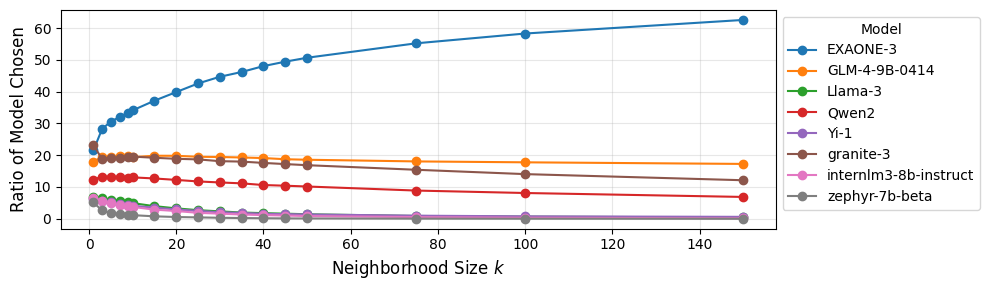

In [96]:
import matplotlib.pyplot as plt

# Melt into long format for easier plotting
df_long = all_model_counts.copy()
df_long["k"] = df_long["k"].astype(int)

# Plot
plt.figure(figsize=(10, 3))
for model, group in df_long.groupby("model"):
    plt.plot(group["k"], group["count"], marker="o", label=model)

#plt.title("Model Scores vs. k", fontsize=14)
plt.xlabel("Neighborhood Size $k$", fontsize=12)
plt.ylabel("Ratio of Model Chosen", fontsize=12)
plt.legend(title="Model", bbox_to_anchor=(1.0, 1.0), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

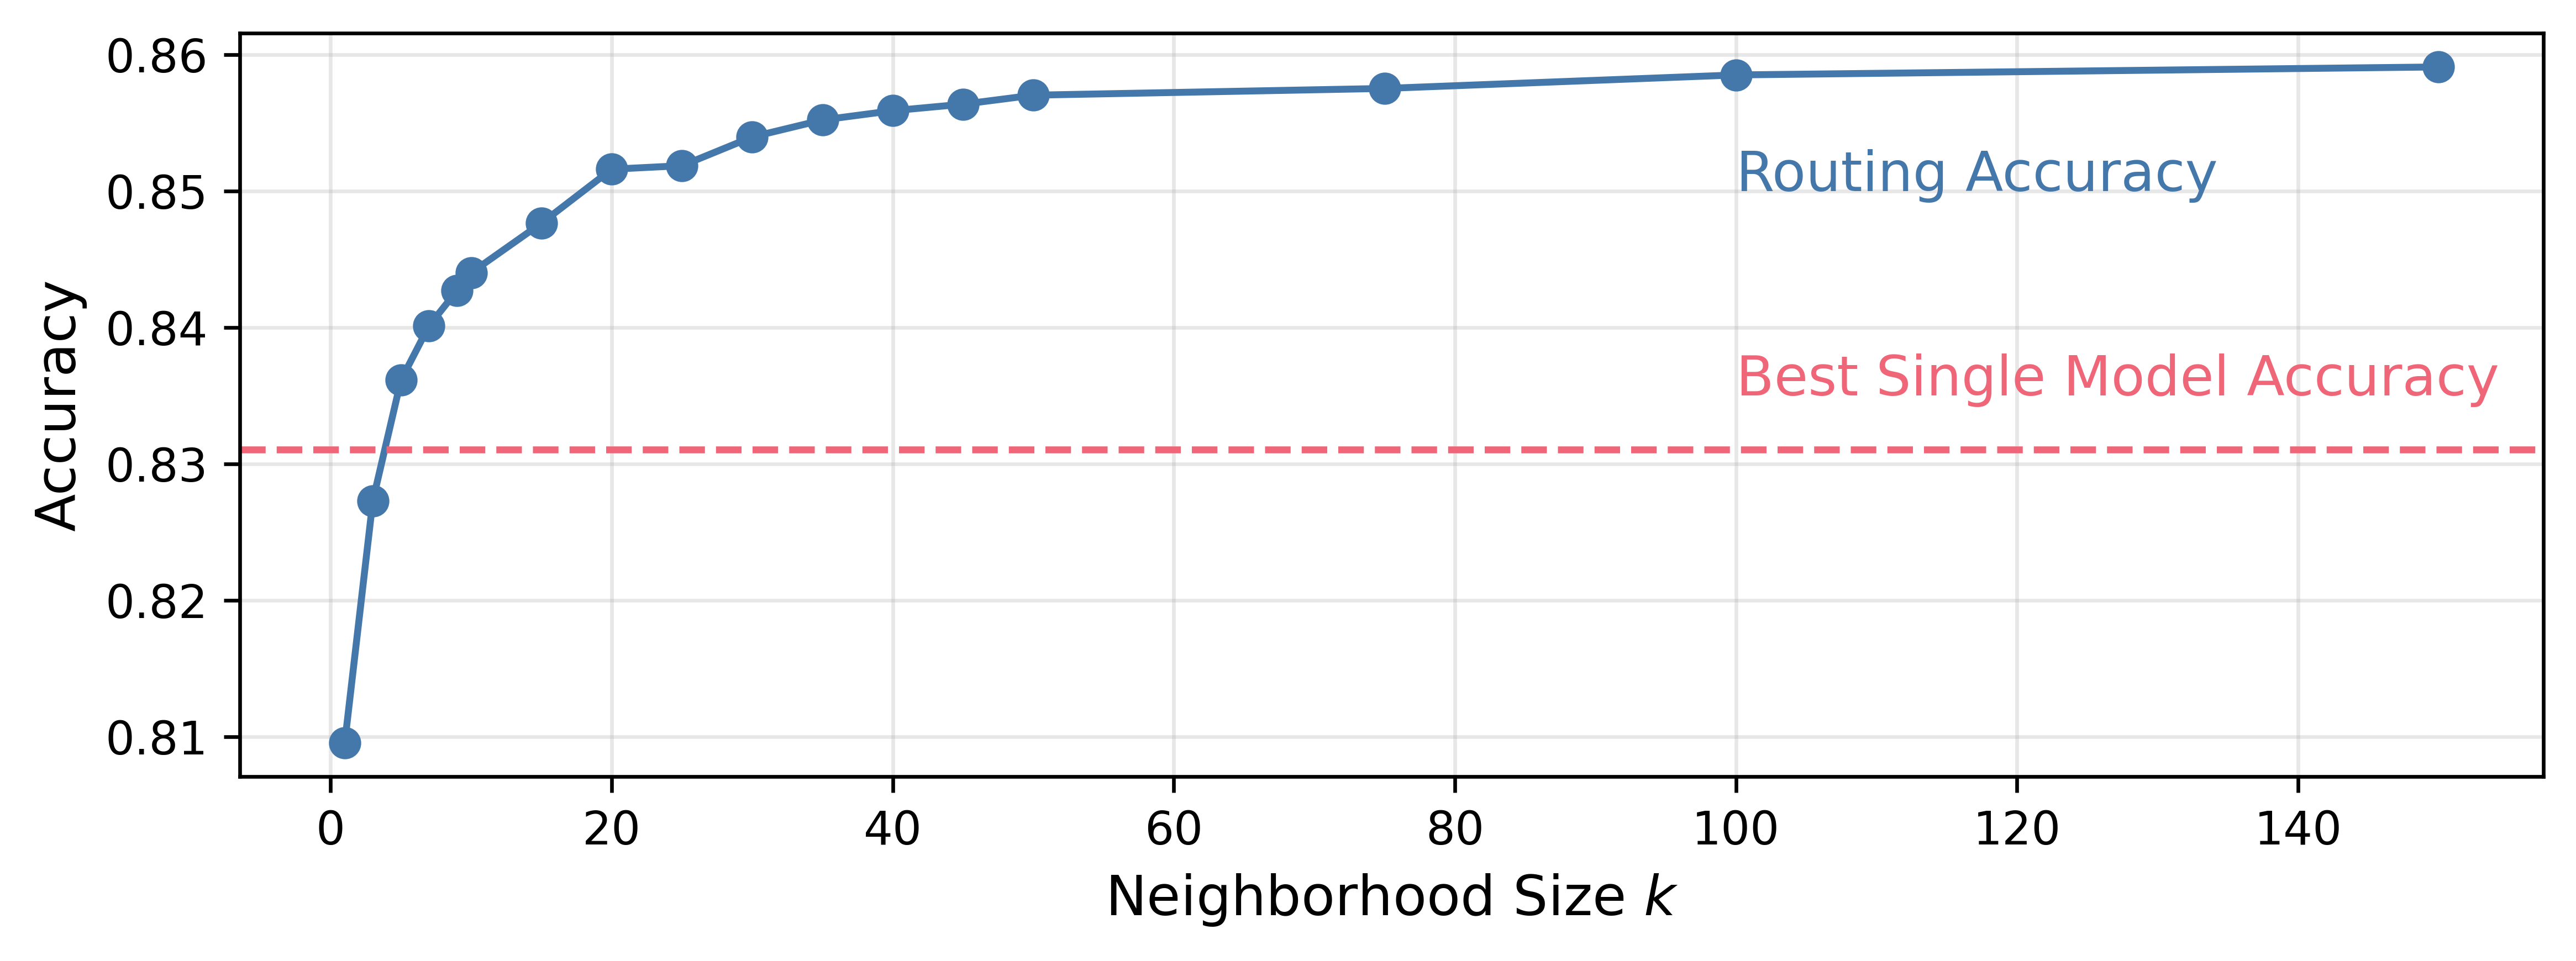

In [113]:
import seaborn as sns

plt.figure(figsize=(8, 3), dpi=600)
ax = plt.gca()
plt.plot(ks, routing_accuracies, marker="o", label="Routing Accuracy", color="#4477AA")
plt.text(100, 0.85, "Routing Accuracy", color="#4477AA", fontsize=12)
#plt.plot(ks, gains, marker="o", label="Gain")

# Draw horizontal line at best single model accuracy
plt.axhline(routing_accuracies[0] - gains[0], color="#EE6677", linestyle="--", label="Best Single Model Accuracy")
plt.text(100, 0.835, "Best Single Model Accuracy", color="#EE6677", fontsize=12)

#plt.title("Model Scores vs. k", fontsize=14)
plt.xlabel("Neighborhood Size $k$", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
#plt.legend(title="Model", bbox_to_anchor=(1.0, 1.0), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [73]:
train_predictions_neighbors = np.take(model_p_yes, I, axis=0).transpose(0, 2, 1)
best_models = np.argmax(np.mean(train_predictions_neighbors, axis=2), axis=1)

test_answers = model_answers[test_indices]
test_predictions = test_answers[np.arange(len(test_answers)), best_models]
test_predictions.shape

(54580,)

In [74]:
from collections import Counter

cnts = Counter(best_models.tolist())
total_cnts = sum(cnts.values())
for model_id, model in enumerate(models):
    print(f"{model}: {cnts[model_id] / total_cnts * 100:.2f}%")

granite-3: 14.05%
zephyr-7b-beta: 0.02%
GLM-4-9B-0414: 17.76%
Qwen2: 8.11%
Llama-3: 0.67%
internlm3-8b-instruct: 0.33%
Yi-1: 0.77%
EXAONE-3: 58.29%


In [75]:
test_answers.mean(axis=0)

array([0.78046904, 0.53693661, 0.81559179, 0.79530964, 0.70020154,
       0.68677171, 0.69276292, 0.83105533])

In [76]:
np.mean(test_predictions)

0.8585012825210699